In [19]:
import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import bisect
from scipy.spatial import cKDTree


In [21]:
# given plt file directory
# get the flame front point 
def read_get_flamex(d1):
    import yt
    import numpy as np
    import pandas as pd
    #load ds
    ds = yt.load(d1)
    ds.force_periodicity()
    # fields we will load per grid
    grad_keys = [
        ("boxlib", "Y(H2)_gradient_x"),
        ("boxlib", "Y(H2)_gradient_y"),
        ("boxlib", "Y(H2)_gradient_z"),
    ]
    Tkey = ("boxlib", "temp")
    
    # Collect chunks here
    chunks = []
    for g in ds.index.grids:
   
        if float(g.LeftEdge[0]) >= 0.07:
            continue
    
        # Pull minimal fields first (to build mask cheaply)
        x = g[("index", "x")].ndarray_view().ravel()
        T = g[Tkey].ndarray_view().ravel()
    
        mask = (T > 310.0) & (x < 0.07)
        if not np.any(mask):
            continue
    
        # Now pull only what you need (still per-grid, so small)
        y  = g[("index", "y")].ndarray_view().ravel()
        z  = g[("index", "z")].ndarray_view().ravel()
    
        data = {
            "x": x[mask],
            "y": y[mask],
            "z": z[mask],
            "T": T[mask],
        }
        chunks.append(pd.DataFrame(data))
    
    df_350 = pd.concat(chunks, ignore_index=True)
    #print(df_350['x'].min(),df_350['x'].max())
    x_cold_region = df_350['x'].min()-0.003

    return x_cold_region





# get flame region cut df
def get_flame_cut(d1,Tcut:float=315,x_cold_region:float=0):
    import yt
    import numpy as np
    import pandas as pd
    #load ds
    ds = yt.load(d1)
    ds.force_periodicity()
    # add the 
    ds.add_gradient_fields(("boxlib", "Y(H2)"))
    Tkey = ("boxlib", "temp")
    mass_fields = [f for f in ds.field_list if "Y(" in f[1]]
    # fields we will load per grid
    grad_keys = [
        ("boxlib", "Y(H2)_gradient_x"),
        ("boxlib", "Y(H2)_gradient_y"),
        ("boxlib", "Y(H2)_gradient_z"),
    ]
  

    # Collect chunks here
    chunks = []
    
    
    for g in ds.index.grids:
        # Quick reject: if this grid is entirely to the right of x=0.07, skip it
    
        # Pull minimal fields first (to build mask cheaply)
        x = g[("index", "x")].ndarray_view().ravel()
        T = g[Tkey].ndarray_view().ravel()
    
    
        """
        Just cut the region at the boundary of isothermal wall x=0.07
        If need to find points of flame at isothermal wall, make sure set the value larger than 0.07 (e.g. x< 0.075)
        """
        mask = (x>=x_cold_region) & (x < 0.075)
        if not np.any(mask):
            continue
    
        # Now pull only what you need (still per-grid, so small)
        y  = g[("index", "y")].ndarray_view().ravel()
        z  = g[("index", "z")].ndarray_view().ravel()
        dx = g[("index", "dx")].ndarray_view().ravel()
    
        gh2x = g[grad_keys[0]].ndarray_view().ravel()
        gh2y = g[grad_keys[1]].ndarray_view().ravel()
        gh2z = g[grad_keys[2]].ndarray_view().ravel()
        gh2mag = np.sqrt(gh2x*gh2x + gh2y*gh2y + gh2z*gh2z)

        heat_release = g[('boxlib', 'HeatRelease')].ndarray_view().ravel()
        data = {
            "x": x[mask],
            "y": y[mask],
            "z": z[mask],
            "T": T[mask],
            "gridsize": dx[mask],
            "gh2x": gh2x[mask],
            "gh2y": gh2y[mask],
            "gh2z": gh2z[mask],
            "gh2mag": gh2mag[mask],
            "Q":heat_release[mask],
        }
            # mass fractions (only masked cells)
        for f in mass_fields:
            data[f[1]] = g[f].ndarray_view().ravel()[mask]
    
        chunks.append(pd.DataFrame(data))




    if len(chunks) == 0:
        raise RuntimeError("No cells found for (T>350) & (x<0.07).")

    df_cut = pd.concat(chunks, ignore_index=True)
    df_cut['global_index'] =df_cut.index
    
    min_idx = df_cut[df_cut['T']>Tcut]['x'].idxmin()
    #print(min_idx)
    #return df_cut, [df_cut['x'].iloc[min_idx], df_cut['y'].iloc[min_idx], df_cut['z'].iloc[min_idx] ]
    return df_cut, min_idx


In [47]:
def find_pathline(df, x0,y0,z0,cutoff_value,max_length,curr_dx):
    pathline = []
    pathline_dict =[]
    find_next_point_cubic(df,x0,y0,z0,cutoff_value,max_length,curr_dx,pathline,pathline_dict)
    
    return pathline,pathline_dict




def find_next_point_cubic(df,x0,y0,z0,cutoff_value,max_length,curr_dx,pathline,pathline_dict):
    # if the line is long enough, then return
    if len(pathline)>=2:
        pt0 = pathline[0]
        ptlast = pathline[-1]
        distance = ((pt0[0] - ptlast[0] )**2  + (pt0[1] - ptlast[1]  )**2 + (pt0[2] - ptlast[2]  )**2 )**0.5
        if distance >= cutoff_value:
            return 
    if len(pathline_dict) >= max_length:
            return 

    temp_weight_dict = get_weight_w_point(df,x0,y0,z0,curr_dx)
    if len(temp_weight_dict)==0:
        return
    #print(temp_weight_dict)

    # make sure the indexes of pathline and pathline dict are aligned
    pathline.append([x0,y0,z0])
    pathline_dict.append(temp_weight_dict)


    # that's the c_i/ |c| part 
    x_dirc, y_dirc, z_dirc = 0,0,0
    next_dx  =  0
    for k,v in temp_weight_dict.items():
        x_dirc += (df['gh2x'].iloc[k] * v)
        y_dirc += (df['gh2y'].iloc[k] * v)
        z_dirc += (df['gh2z'].iloc[k] * v)
        #next_dx = max(next_dx, df['gridsize'].iloc[k])
    next_dx = curr_dx
    norm_dist = (x_dirc**2+ y_dirc**2+z_dirc**2)**0.5
    norm_dist_sqrd = norm_dist**2
    x_next = x0  - x_dirc/norm_dist_sqrd * (0.75*next_dx)
    y_next = y0  - y_dirc/norm_dist_sqrd * (0.75*next_dx)
    z_next = z0  - z_dirc/norm_dist_sqrd * (0.75*next_dx)
    if z_next <=0:
        return
    #print(f'The next point is x: {x_next}, y: {y_next} , z: {z_next}')

    find_next_point_cubic(df,x_next,y_next,z_next,cutoff_value,max_length,next_dx,pathline,pathline_dict)
        
    return 




"""
need to have 2 separate method to extract points

"""

# supposed to return a directionary/list with 8 pts (index)

"""
def find_pts(df,x0,y0,z0,curr_dx):
    pts_good = []
    coord_dict = {}
    
        
    xbl, xbr = x0 - 4*curr_dx, x0 + 4*curr_dx
    ybl, ybr = y0 - 4*curr_dx, y0 + 4*curr_dx
    zbl, zbr = z0 - 4*curr_dx, z0 + 4*curr_dx

    
     
    if (xbl>0.07) or (xbr>0.07):
        xbl -= 2*curr_dx
        xbr += 2*curr_dx
        ybl -= 2*curr_dx
        ybr += 2*curr_dx
        zbl -= 2*curr_dx
        zbr += 2*curr_dx
    
    # the 01 indiation of cubic
    coord_idx = [[-1,-1,-1], [-1,-1,1], [-1,1,-1],[-1,1,1],
                [1,-1,-1], [1,-1,1], [1,1,-1],[1,1,1], ]

    print(f'for {x0}, {y0}, {z0}.')
    for ec in coord_idx:
        x_edge = xbr if ec[0] ==1 else xbl
        y_edge = ybr if ec[1] ==1 else ybl
        z_edge = zbr if ec[2] ==1 else zbl
        print(f'xedge is {x_edge}')

        subxl, subxr = min(x_edge,x0), max(x_edge,x0)
        subyl, subyr = min(y_edge,y0), max(y_edge,y0)
        subzl, subzr = min(z_edge,z0), max(z_edge,z0)

        print(f'Find from x : {subxl} to {subxr}.')
        print(f'Find from y : {subyl} to {subyr}.')
        print(f'Find from z : {subzl} to {subzr}.')

        temp_cut = df[ (df['x'] > subxl) &  (df['x'] <= subxr) & (df['y'] > subyl) &  (df['y'] <= subyr) & (df['z'] > subzl) &  (df['z'] <= subzr)]
        df_cut = temp_cut.copy()

        points = df_cut[['x','y','z']].to_numpy()
        print(points)
        tree = cKDTree(points)
        
        query_point = np.array([x0, y0, z0])
        dist, i_local = tree.query(query_point)
        print(i_local)
        row = df.iloc[int(i_local)] 
        row_cut = df.iloc[int(i_local)]

        # row inside df_cut (guaranteed in-range)
        idx_global = df.index[int(i_local)]  # original df index label
        print(f"find the near point of {df[['x','y','z']].iloc[idx_global]}.  ")
        pts_good.append(idx_global)
        coord_dict[tuple(ec)] = idx_global
        
    

    return pts_good, coord_dict
"""
def find_pts(df,x0,y0,z0,curr_dx):
    pts_good = []
    coord_dict = {}
    
    
    xbl, xbr = x0 - 4*curr_dx, x0 + 4*curr_dx
    ybl, ybr = y0 - 4*curr_dx, y0 + 4*curr_dx
    zbl, zbr = z0 - 4*curr_dx, z0 + 4*curr_dx
    #print(f' trying to find points for {x0},{y0},{z0}')
    # the 01 indiation of cubic
    coord_idx = [[-1,-1,-1], [-1,-1,1], [-1,1,-1],[-1,1,1],
                [1,-1,-1], [1,-1,1], [1,1,-1],[1,1,1], ]


    for ec in coord_idx:
        x_edge = xbr if ec[0] ==1 else xbl
        y_edge = ybr if ec[1] ==1 else ybl
        z_edge = zbr if ec[2] ==1 else zbl

        subxl, subxr = min(x_edge,x0), max(x_edge,x0)
        subyl, subyr = min(y_edge,y0), max(y_edge,y0)
        subzl, subzr = min(z_edge,z0), max(z_edge,z0)


        if subzl <0:
            subzl += curr_dx/2
            subzr += curr_dx/2

        if (subxl >0.07 ) or (subxr >0.07):
            subxl += 3*curr_dx
            subxr += 3*curr_dx

        
        temp_cut = df[ (df['x'] > subxl) &  (df['x'] <= subxr) & (df['y'] > subyl) &  (df['y'] <= subyr) & (df['z'] > subzl) &  (df['z'] <= subzr)]


        
        df_cut = temp_cut.copy()
        #

        
        if (df_cut.shape[0]==0):
            #print(f'no point can be found for x:{subxl } to {subxr }, y: {subyl } to {subyr }, z:{subzl } to {subzr }')
            continue
         
        points = df_cut[['x','y','z']].to_numpy()
        tree = cKDTree(points)
        
        #print(f'subxl: {subxl}, subxr: {subxr}')
        #print(f'subyl: {subyl}, subyr: {subyr}')
        #print(f'subzl: {subzl}, subzr: {subzr}')
        #print(df_cut['x'].min(), df_cut['x'].max())
        query_point = np.array([x0, y0, z0])
        # index is the index of the original df
        # and this index need to be stored and used
        #dist, idx = tree.query(query_point)
        #print(f"for {ec} is nearest index is {idx} with distance {dist} x:{df_out['x'].loc[idx]}, y:{df_out['y'].loc[idx]}, z:{df_out['z'].loc[idx]}.")
        dist, i_local = tree.query(query_point)
        if(subxl>subxr):
            print('something wrong on x !')
            break

        if(subyl>subyr):
            print('something wrong on y !')
            break

        if(subzl>subzr):
            print('something wrong on z!')
            break
        
        idx_global = df_cut['global_index'].iloc[int(i_local)]
        
        #print(f'local index is {i_local} and global index is {idx_global}.')
        #print(f"xyz: {df[['x','y','z']].iloc[idx_global]}")
        
        pts_good.append(idx_global)
        coord_dict[tuple(ec)] = idx_global
        


    return pts_good, coord_dict








In [25]:
#print(pts1[0],pts1[1],pts1[2])
#pathline,pathdict = find_pathline(df1,pts1[0],pts1[1],pts1[2],0.0035,200,34.1e-6  )

In [39]:

def get_weight_w_point(df0,x0,y0,z0,curr_dx):

    df =df0.copy()
    temp_ls, _ = find_pts(df,x0,y0,z0,curr_dx)
    if len(temp_ls)==0:
        return {}
    
    temp_dist = []
    subdf = df[['x', 'y', 'z']].loc[temp_ls]
    #print(f'the length of subdf is {subdf.shape[0]}')
    minv = 1e-12
    currmin = 100
    for i in range(subdf.shape[0]):
        tx = subdf['x'].iloc[i]
        ty = subdf['y'].iloc[i]
        tz = subdf['z'].iloc[i]
        minxyz_pre = [(tx - x0  )**2, (ty - y0  )**2 , (tz- z0  )**2 ] 
        
        minxyz = [ x for x in minxyz_pre if x>0]
        minxyz.append(currmin)
        currmin = min(minxyz)
        #print(f'for current {tx}, {ty}, {tz}, the diff is {minxyz}')

    minv = min(1e-4, currmin/1000)

    

    #print(minv)
    
    for i in range(subdf.shape[0]):
        x_diff = subdf['x'].iloc[i] - x0 if (subdf['x'].iloc[i] - x0)!=0 else minv
        y_diff = subdf['y'].iloc[i] - y0 if (subdf['y'].iloc[i] - y0)!=0 else minv
        z_diff = subdf['z'].iloc[i] - z0 if (subdf['z'].iloc[i] - z0)!=0 else minv

        
        temp_dist.append( 1/( (x_diff)**2 +   (y_diff)**2 +( z_diff)**2) )

    sum_weight = sum(temp_dist)
    weight_dict = {}
    check_ttl=0

    # find way to 
    for i in range(subdf.shape[0]):
        if subdf.index[i] not in weight_dict:
            weight_dict[subdf.index[i]] = temp_dist[i] /  sum_weight
        else:
            weight_dict[subdf.index[i]] += temp_dist[i] /  sum_weight

    #print(check_ttl)
    return weight_dict


def get_T_Mass_from_list(df,pathline,pathline_dict):
    index_col = ['x', 'y', 'z']
    header_col = [ec for ec in df.columns if 'Y('  in ec ]
    header_col.append('T')
    header_col.extend( ['gh2x','gh2y', 'gh2z','Q'])
    full_col = index_col+ header_col
    #final_df = pd.DataFrame(columns=full_col)
    # this list combined 2 items, [index, value]
    # then sort by index. 
    final_list = []
    for i in range(len(pathline_dict)):
        temp_dict = pathline_dict[i]
        temp_target_coord = pathline[i]
        
        temp_intp_list = []
        temp_intp_list.extend(pathline[i])
        temp_intp_weight = []
        #print(temp_dict)
        w=pd.Series(temp_dict, name="weight")
        temo_subdf = df[header_col].loc[w.index].copy()
        temo_subdf["weight"] = w
        #print(temo_subdf)
        #num_cols = df_selected.select_dtypes(include="number").columns
        df_weighted = temo_subdf[header_col].multiply(temo_subdf["weight"], axis=0)
        
        for i in range(len(header_col)):
            #print(df_weighted[header_col[i]])
            temp_intp_list.append(sum(df_weighted[header_col[i]]))
        final_list.append(temp_intp_list)
    
        
    return pd.DataFrame(final_list,columns = full_col)
            
            


In [41]:

#pt1 = read_get_flamex("/Users/potato/Downloads/plt59250",315)
#df1,min_idx = get_flame_cut("/Users/potato/Downloads/plt59250",315,pt1)



In [15]:

d1 = '/home/u0890475/Downloads/plt59250'
pt1 = read_get_flamex(d1)
df1,min_idx = get_flame_cut(d1,302,pt1)
df1.iloc[min_idx]

yt : [INFO     ] 2026-03-04 15:11:20,408 Parameters: current_time              = 0.1696800000000185
yt : [INFO     ] 2026-03-04 15:11:20,409 Parameters: domain_dimensions         = [384  64  64]
yt : [INFO     ] 2026-03-04 15:11:20,409 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-04 15:11:20,409 Parameters: domain_right_edge         = [0.105  0.0175 0.0175]
yt : [INFO     ] 2026-03-04 15:11:21,462 Parameters: current_time              = 0.1696800000000185
yt : [INFO     ] 2026-03-04 15:11:21,462 Parameters: domain_dimensions         = [384  64  64]
yt : [INFO     ] 2026-03-04 15:11:21,463 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-04 15:11:21,463 Parameters: domain_right_edge         = [0.105  0.0175 0.0175]


x               6.550537e-02
y               6.750488e-03
z               1.879883e-04
T               3.021166e+02
gridsize        3.417969e-05
gh2x           -2.071868e+00
gh2y           -5.047711e-01
gh2z            3.583653e-01
gh2mag          2.162373e+00
Q               2.499052e+03
Y(H)            3.709566e-15
Y(H2)           1.271198e-02
Y(H2O)          7.431675e-03
Y(H2O2)         3.979292e-05
Y(HO2)          2.974061e-06
Y(N2)           7.569477e-01
Y(O)            4.912102e-11
Y(O2)           2.228658e-01
Y(OH)           6.817469e-12
global_index    2.983981e+06
Name: 2983981, dtype: float64

In [49]:


pathline,pathdict = find_pathline(df1,df1['x'].iloc[min_idx],df1['y'].iloc[min_idx],df1['z'].iloc[min_idx],0.0035,520,34.1e-6  )
df_p1 = get_T_Mass_from_list(df1,pathline,pathdict)
df_p1

,x,y,z,Y(H),Y(H2),Y(H2O),Y(H2O2),Y(HO2),Y(N2),Y(O),Y(O2),Y(OH),T,gh2x,gh2y,gh2z,Q
0,0.065505,0.006750,0.000188,3.709566e-15,0.012712,0.007432,0.000040,0.000003,0.756948,4.912102e-11,0.222866,6.817469e-12,302.116556,-2.071868,-0.504771,0.358365,2.499052e+03
1,0.065517,0.006753,0.000186,3.486757e-15,0.012688,0.007668,0.000041,0.000003,0.756939,5.611384e-11,0.222660,8.402216e-12,302.588507,-2.214291,-0.530901,0.315569,2.959345e+03
2,0.065527,0.006756,0.000185,3.725795e-15,0.012654,0.007980,0.000043,0.000004,0.756929,6.761282e-11,0.222390,1.093393e-11,303.376192,-2.417385,-0.583557,0.317262,3.664182e+03
3,0.065537,0.006758,0.000183,3.970451e-15,0.012640,0.008095,0.000044,0.000004,0.756926,7.314525e-11,0.222291,1.214011e-11,303.752110,-2.501523,-0.608287,0.346094,3.982805e+03
4,0.065547,0.006760,0.000182,5.119951e-15,0.012605,0.008345,0.000046,0.000004,0.756913,8.735083e-11,0.222088,1.604392e-11,304.626438,-2.724746,-0.646782,0.340793,5.021830e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.068112,0.007323,0.000142,8.151787e-06,0.000139,0.153231,0.000020,0.000058,0.757320,1.409903e-04,0.088717,3.657357e-04,1009.000032,-0.069506,-0.007071,-0.081909,1.582092e+08
496,0.068266,0.007339,0.000323,2.236591e-05,0.000133,0.152885,0.000008,0.000023,0.758617,4.911432e-04,0.086381,1.438884e-03,1374.655135,-0.065822,-0.005842,0.135886,1.400670e+08
497,0.068339,0.007345,0.000170,8.955337e-06,0.000123,0.151708,0.000016,0.000048,0.757253,1.704031e-04,0.090227,4.453138e-04,1074.551798,-0.055396,-0.004784,-0.050573,1.395293e+08
498,0.068590,0.007367,0.000399,2.366915e-05,0.000128,0.150700,0.000007,0.000019,0.758686,5.788329e-04,0.088022,1.835855e-03,1457.112202,-0.055147,0.012328,0.190551,1.228124e+08


In [33]:
print(df_p1)
cline = []
cline.append([1- df_p1['Y(H2)'] / 0.01304])
t_profile = []
t_profile.append([df_p1['T']])
t_profile

            x         y         z          Y(H)     Y(H2)    Y(H2O)   Y(H2O2)  \
0    0.065505  0.006750  0.000188  3.709566e-15  0.012712  0.007432  0.000040   
1    0.065511  0.006752  0.000187  3.597496e-15  0.012704  0.007512  0.000040   
2    0.065517  0.006753  0.000186  3.483844e-15  0.012686  0.007687  0.000041   
3    0.065523  0.006755  0.000185  3.620536e-15  0.012664  0.007884  0.000043   
4    0.065528  0.006756  0.000184  3.754083e-15  0.012652  0.007998  0.000044   
..        ...       ...       ...           ...       ...       ...       ...   
445  0.066086  0.006885  0.000165  2.069011e-05  0.006756  0.066896  0.000078   
446  0.066087  0.006886  0.000165  2.466994e-05  0.006580  0.069457  0.000071   
447  0.066088  0.006886  0.000165  2.480085e-05  0.006575  0.069533  0.000071   
448  0.066088  0.006886  0.000165  2.494911e-05  0.006570  0.069614  0.000071   
449  0.066089  0.006886  0.000165  2.511557e-05  0.006564  0.069702  0.000070   

       Y(HO2)     Y(N2)    

[[0      302.116556
  1      302.270408
  2      302.629639
  3      303.113836
  4      303.432111
            ...    
  445    787.982803
  446    806.097442
  447    806.661007
  448    807.291208
  449    807.991949
  Name: T, Length: 450, dtype: float64]]

In [ ]:
df_whole_front = df1[(df1['x']<=0.07) & (df1['z'] > 2*34e-6) & (df1['y']<=0.015) & (df1['y'] >=0.002) & (df1['T']>=305) ]
df_sub = df_whole_front.loc[df_whole_front.groupby('y')['x'].idxmin()].reset_index(drop=True)
df_fb = df_sub[df_sub['x']< df1['x'].iloc[min_idx]+0.002 ] 
df_stable = df_sub[df_sub['x']> 0.069]

In [ ]:
print(df_fb.shape[0])
print(df_stable.shape[0])
df_sub['x'].max()
#df_stable = df_sub[df_sub['x']> 0.069]

In [ ]:
xs2 = df_sub['x'].iloc[1]
ys2 = df_sub['y'].iloc[1]
zs2 = df_sub['z'].iloc[1]
print(f'try this {xs2}, {ys2},{zs2}.')

In [23]:
pl2,pd2 = find_pathline(df1,  xs2  ,  ys2 ,  zs2  ,0.0035,250,68.1e-6  )
df_p2 = get_T_Mass_from_list(df1,pl2,pd2)

In [53]:
sf_oh=[]
fb_oh=[]

sf_h =[]
fb_h =[]

sf_o2=[]
fb_o2=[]

sf_o=[]
fb_o=[]

sf_ho2=[]
fb_ho2=[]

sf_h2o2=[]
fb_h2o2=[]

sf_h2o=[]
fb_h2o=[]

sf_h2=[]
fb_h2=[]

sf_cline= []
sf_t = []
fb_cline = []
fb_t = []
x_cutoff = df1['x'].iloc[min_idx]+0.002
print(x_cutoff)

sf_coord = []
fb_coord = []

sf_pl = []
fb_pl = []

0.06753955078125


In [55]:

for i in range(df_sub.shape[0]):
    temp_xs  = df_sub['x'].iloc[i]
    temp_ys  = df_sub['y'].iloc[i]
    temp_zs  = df_sub['z'].iloc[i]
    if (temp_xs > x_cutoff) and (temp_xs<0.069):
        continue

    try:
        tpl2,tpd2 = find_pathline(df1,  temp_xs  ,  temp_ys ,  temp_zs  ,0.0035,250,68.1e-6  )
        temp_df2 = get_T_Mass_from_list(df1,tpl2,tpd2) 
        temp_cline = [1- temp_df2['Y(H2)'] /0.01304 ]
        temp_oh = [temp_df2['Y(OH)']]
        temp_o2 = [temp_df2['Y(O2)']]
        temp_o = [temp_df2['Y(O)']]
        temp_ho2 = [temp_df2['Y(HO2)']]
        temp_h2o2 = [temp_df2['Y(H2O2)']]
        temp_h2o = [temp_df2['Y(H2O)']]    
        temp_t2 = [temp_df2['T'] ]
        temp_h = [temp_df2['Y(H)']]
        if temp_xs<=x_cutoff:
            fb_oh.append(temp_oh)
            fb_o2.append(temp_o2)
            fb_o.append(temp_o)
            fb_ho2.append(temp_ho2)
            fb_h2o2.append(temp_h2o2)
            fb_h2o.append(temp_h2o)
            #fb_h2.append(temp_h2)
            fb_cline.append(temp_cline)
            fb_t.append(temp_t2)
            fb_coord.append([temp_xs,temp_ys,temp_zs])
            fb_h.append(temp_h)
            fb_pl.append(tpl2)
        else:
            sf_oh.append(temp_oh)
            sf_o2.append(temp_o2)
            sf_o.append(temp_o)
            sf_ho2.append(temp_ho2)
            sf_h2o2.append(temp_h2o2)
            sf_h2o.append(temp_h2o)
            sf_cline.append(temp_cline)
            sf_t.append(temp_t2)
            sf_coord.append([temp_xs,temp_ys,temp_zs])
            sf_h.append(temp_h)
            sf_pl.append(tpl2)
        
    
        print(f'The point of {temp_xs}, {temp_ys},{temp_zs} find c line.')
    except:
        print(f'The point of {temp_xs}, {temp_ys},{temp_zs} cant get progress variable line')


The point of 0.06969238281249998, 0.0020166015625000004,0.00010253906250000001 find c line.
The point of 0.06967529296874998, 0.0020336914062500005,8.544921875000001e-05 find c line.
The point of 0.06986328124999999, 0.00205078125,0.00013671875 find c line.
The point of 0.06967529296874998, 0.00206787109375,8.544921875000001e-05 find c line.
The point of 0.06969238281249998, 0.0020849609375000002,0.00010253906250000001 find c line.
The point of 0.06967529296874998, 0.0021020507812500003,8.544921875000001e-05 find c line.
The point of 0.06979492187499999, 0.0021191406250000004,6.8359375e-05 find c line.
The point of 0.06967529296874998, 0.00213623046875,8.544921875000001e-05 find c line.
The point of 0.06969238281249998, 0.0021533203125,0.00010253906250000001 find c line.
The point of 0.06967529296874998, 0.00217041015625,8.544921875000001e-05 find c line.
The point of 0.06967529296874998, 0.0022045898437500003,8.544921875000001e-05 find c line.
The point of 0.06969238281249998, 0.00222

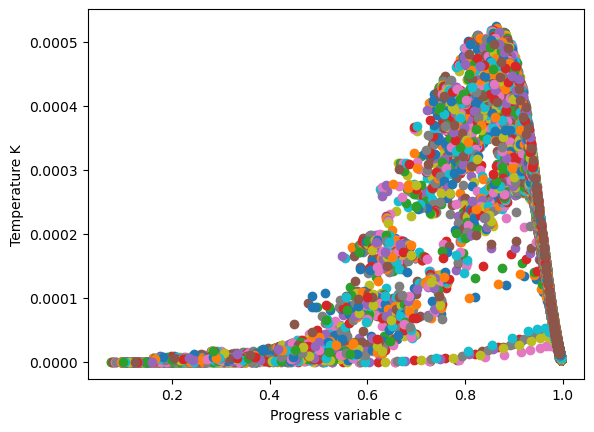

In [57]:
import matplotlib.pyplot as plt
for i in range(len(sf_cline)):
    plt.scatter(sf_cline[i],sf_h[i])

plt.xlabel('Progress variable c')
plt.ylabel('Temperature K')
plt.show()

In [47]:
tpl2

[[0.06969238281249998, 0.0020166015625000004, 0.00010253906250000001],
 [0.06974901293052356, 0.0020172201881414505, 6.472032329639e-05],
 [0.0698120209121631, 0.002017544444204089, 3.8884319199042824e-05],
 [0.06987733137928218, 0.0020176018089891907, 1.9593140023858306e-05],
 [0.06993203280955604, 0.00201756631875381, 6.0156205322679545e-05],
 [0.06999625147794399, 0.0020174021365977285, 3.749465915525442e-05],
 [0.07006015845201441, 0.0020171533388331224, 1.3969209853805724e-05],
 [0.07007646029807109, 0.0020170580598786294, 8.00891821546562e-05],
 [0.07012962878677959, 0.0020166446262626066, 3.753861363790126e-05],
 [0.07018880265048912, 0.0020161164315150074, 3.837206189620862e-06],
 [0.07019288622984411, 0.0020160647003321795, 7.181464144232966e-05],
 [0.07024008107381811, 0.0020154573686632597, 2.2724032864783907e-05],
 [0.07024454567236572, 0.002015388344576446, 9.067749190466012e-05],
 [0.07028508339022685, 0.002014750032780491, 3.5960986271876595e-05],
 [0.07029822040635038, 

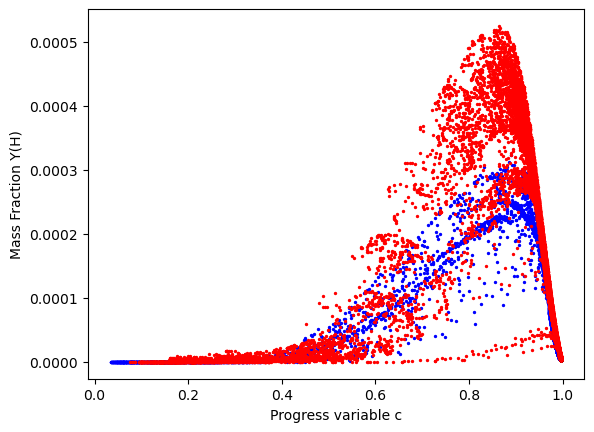

In [79]:
import matplotlib.pyplot as plt
for i in range(len(fb_cline)):
    plt.scatter(fb_cline[i],fb_h[i],c='b',label='flashback',s=2)
for i in range(len(sf_cline)):
    plt.scatter(sf_cline[i],sf_h[i],c='r',label = 'stableflame',s=2)
plt.xlabel('Progress variable c')
plt.ylabel('Mass Fraction Y(H)')


plt.savefig('mass fraction of Y(H) vs progress variable c.png',dpi=600)
plt.show()

In [75]:
pwd

'/home/u0890475/Downloads'

In [83]:
print(len(sf_cline))

496


In [85]:
print(len(fb_cline))

162


In [ ]:
sf_oh=[]
fb_oh=[]

sf_h =[]
fb_h =[]

sf_o2=[]
fb_o2=[]

sf_o=[]
fb_o=[]

sf_ho2=[]
fb_ho2=[]

sf_h2o2=[]
fb_h2o2=[]

sf_h2o=[]
fb_h2o=[]

sf_h2=[]
fb_h2=[]

sf_cline= []
sf_t = []
fb_cline = []
fb_t = []
x_cutoff = df1['x'].iloc[min_idx]+0.002
print(x_cutoff)

sf_coord = []
fb_coord = []

sf_pl = []
fb_pl = []


for i in range(df_sub.shape[0]):
    temp_xs  = df_sub['x'].iloc[i]
    temp_ys  = df_sub['y'].iloc[i]
    temp_zs  = df_sub['z'].iloc[i]
    if (temp_xs > x_cutoff) and (temp_xs<0.069):
        continue

    try:
        tpl2,tpd2 = find_pathline(df1,  temp_xs  ,  temp_ys ,  temp_zs  ,0.0035,250,68.1e-6  )
        temp_df2 = get_T_Mass_from_list(df1,tpl2,tpd2) 
        temp_cline = [1- temp_df2['Y(H2)'] /0.01304 ]
        temp_oh = [temp_df2['Y(OH)']]
        temp_o2 = [temp_df2['Y(O2)']]
        temp_o = [temp_df2['Y(O)']]
        temp_ho2 = [temp_df2['Y(HO2)']]
        temp_h2o2 = [temp_df2['Y(H2O2)']]
        temp_h2o = [temp_df2['Y(H2O)']]    
        temp_t2 = [temp_df2['T'] ]
        temp_h = [temp_df2['Y(H)']]
        if temp_xs<=x_cutoff:
            fb_oh.append(temp_oh)
            fb_o2.append(temp_o2)
            fb_o.append(temp_o)
            fb_ho2.append(temp_ho2)
            fb_h2o2.append(temp_h2o2)
            fb_h2o.append(temp_h2o)
            #fb_h2.append(temp_h2)
            fb_cline.append(temp_cline)
            fb_t.append(temp_t2)
            fb_coord.append([temp_xs,temp_ys,temp_zs])
            fb_h.append(temp_h)
            fb_pl.append(tpl2)
        else:
            sf_oh.append(temp_oh)
            sf_o2.append(temp_o2)
            sf_o.append(temp_o)
            sf_ho2.append(temp_ho2)
            sf_h2o2.append(temp_h2o2)
            sf_h2o.append(temp_h2o)
            sf_cline.append(temp_cline)
            sf_t.append(temp_t2)
            sf_coord.append([temp_xs,temp_ys,temp_zs])
            sf_h.append(temp_h)
            sf_pl.append(tpl2)
        
    
        print(f'The {i}th point of {temp_xs}, {temp_ys},{temp_zs} find c line.')
    except:
        print(f'The {i}th point of {temp_xs}, {temp_ys},{temp_zs} cant get progress variable line')


import matplotlib.pyplot as plt
for i in range(len(fb_cline)):
    plt.scatter(fb_cline[i],fb_h[i],c='b',label='flashback',s=2)
for i in range(len(sf_cline)):
    plt.scatter(sf_cline[i],sf_h[i],c='r',label = 'stableflame',s=2)
plt.xlabel('Progress variable c')
plt.ylabel('Mass Fraction Y(H)')


plt.savefig('mass fraction of Y(H) vs progress variable c.png',dpi=600)
plt.show()

In [65]:
def flame_cline(df1,df_coord,slabel="",savedir = "/media/u0890475/6f7f5b18-6951-4d23-9e1b-146d3d4c2671/SW_cache/amr4_anz"):
    sf_oh=[]
    sf_h =[]    
    sf_o2=[]    
    sf_o=[]
    sf_ho2=[]    
    sf_h2o2=[]   
    sf_h2o=[]  
    sf_h2=[]  
    sf_cline= []
    sf_t = []
    sf_pl=[]
    sf_coord=[]
    fln=[]
    for i in range(df_coord.shape[0]):
        temp_xs  = df_coord['x'].iloc[i]
        temp_ys  = df_coord['y'].iloc[i]
        temp_zs  = df_coord['z'].iloc[i]
        #print(temp_xs,temp_ys,temp_zs)

        try:
            tpl2,tpd2 = find_pathline(df1,  temp_xs  ,  temp_ys ,  temp_zs  ,0.0035,450,68.1e-6  )
            if len(tpl2) ==0:
                continue
            temp_df2 = get_T_Mass_from_list(df1,tpl2,tpd2) 
            #print('found line dataframe!')
            temp_cline = [1- temp_df2['Y(H2)'] /0.01304 ]
            temp_oh = [temp_df2['Y(OH)']]
            temp_o2 = [temp_df2['Y(O2)']]
            temp_o = [temp_df2['Y(O)']]
            temp_ho2 = [temp_df2['Y(HO2)']]
            temp_h2o2 = [temp_df2['Y(H2O2)']]
            temp_h2o = [temp_df2['Y(H2O)']]    
            temp_t2 = [temp_df2['T'] ]
            temp_h = [temp_df2['Y(H)']]
            #print('Section 1 is ok')
            sf_oh.append(temp_oh)
            sf_o2.append(temp_o2)
            sf_o.append(temp_o)
            sf_ho2.append(temp_ho2)
            sf_h2o2.append(temp_h2o2)
            #print('section 2a is ok')
            sf_h2o.append(temp_h2o)
            sf_cline.append(temp_cline)
            #print('section 2b is ok')
            sf_t.append(temp_t2)
            sf_coord.append([temp_xs,temp_ys,temp_zs])
            #print('section 2c is ok')
            sf_h.append(temp_h)
            sf_pl.append(tpl2)
            #print('secont 2d is ok')
            print(f'The point of {temp_xs}, {temp_ys},{temp_zs} find c line.')
        except:
            fln.append([temp_xs,temp_ys,temp_zs])
            print(f'The point of {temp_xs}, {temp_ys},{temp_zs} cant get progress variable line')
        

    
    import matplotlib.pyplot as plt
    for i in range(len(sf_cline)):
        plt.scatter(sf_cline[i],sf_h[i],c='b',s=2)
        plt.title(f'Progress Variable vs Y(H) of {slabel}.')
        plt.savefig(f'{savedir}/Progress Variable vs Y(H) of {slabel}.png',dpi=600)
        plt.show()

        plt.scatter(sf_cline[i],sf_oh[i],c='b',s=2)
        plt.title(f'Progress Variable vs Y(OH) of {slabel}.')
        plt.savefig(f'{savedir}/Progress Variable vs Y(OH) of {slabel}.png',dpi=600)
        plt.show()

        plt.scatter(sf_cline[i],sf_o[i],c='b',s=2)
        plt.title(f'Progress Variable vs Y(O) of {slabel}.')
        plt.savefig(f'{savedir}/Progress Variable vs Y(O) of {slabel}.png',dpi=600)
        plt.show()

        plt.scatter(sf_cline[i],sf_o2[i],c='b',s=2)
        plt.title(f'Progress Variable vs Y(O2) of {slabel}.')
        plt.savefig(f'{savedir}/Progress Variable vs Y(O2) of {slabel}.png',dpi=600)
        plt.show()

        """
        plt.scatter(sf_cline[i],sf_h2[i],c='b',s=2)
        plt.title(f'Progress Variable vs Y(H2) of {slabel}.')
        plt.savefig(f'{savedir}/Progress Variable vs Y(H2) of {slabel}.png',dpi=600)
        plt.show()
        """
        
        plt.scatter(sf_cline[i],sf_h2o2[i],c='b',s=2)
        plt.title(f'Progress Variable vs Y(H2O2) of {slabel}.')
        plt.savefig(f'{savedir}/Progress Variable vs Y(H2O2) of {slabel}.png',dpi=600)
        plt.show()

        plt.scatter(sf_cline[i],sf_h2o[i],c='b',s=2)
        plt.title(f'Progress Variable vs Y(H2O) of {slabel}.')
        plt.savefig(f'{savedir}/Progress Variable vs Y(H2O) of {slabel}.png',dpi=600)
        plt.show()

        plt.scatter(sf_cline[i],sf_ho2[i],c='b',s=2)
        plt.title(f'Progress Variable vs Y(HO2) of {slabel}.')
        plt.savefig(f'{savedir}/Progress Variable vs Y(HO2) of {slabel}.png',dpi=600)
        plt.show()

    return {'Y(H2)': sf_h2, 'Y(H)':sf_h, 'Y(HO2)':sf_ho2, 'Y(H2O)':sf_h2o, 'Y(H2O2)':sf_h2o2,
            'Y(O)':  sf_o,'Y(OH)':sf_oh, 'Y(O2)':sf_o2,}


    

In [55]:
dr1_y_fw = '/home/u0890475/Downloads/y_forward.csv'
dr1_y_bw = '/home/u0890475/Downloads/y_backward.csv'
dr1_y_st = '/home/u0890475/Downloads/y_stable.csv'
dr1_y_fb = '/home/u0890475/Downloads/y_flashback.csv'

df_y_fw= pd.read_csv(dr1_y_fw)
df_y_bw= pd.read_csv(dr1_y_bw)
df_y_st= pd.read_csv(dr1_y_st)
df_y_fb= pd.read_csv(dr1_y_fb)

In [57]:
df_y_bw

,x,y,z
0,0.069436,0.000017,0.000188
1,0.069487,0.000034,0.000103
2,0.069470,0.000051,0.000222
3,0.069470,0.000085,0.000222
4,0.069470,0.000120,0.000120
...,...,...,...
205,0.069436,0.017415,0.000188
206,0.069521,0.017432,0.000068
207,0.069436,0.017449,0.000188
208,0.069487,0.017466,0.000308


In [ ]:
dr1,pt1 = flame_cline(df1,df_y_bw,slabel="flackward")

The point of 0.0694360351562499, 1.708984375e-05,0.00018798828125 find c line.
The point of 0.0694873046874999, 3.41796875e-05,0.0001025390625 find c line.
The point of 0.0694702148437499, 5.1269531250000005e-05,0.00022216796875 find c line.
The point of 0.0694702148437499, 8.544921875000001e-05,0.00022216796875 find c line.
The point of 0.0694702148437499, 0.00011962890625,0.00011962890625 find c line.
The point of 0.0695556640624999, 0.0005126953125,0.0001025390625 find c line.
The point of 0.0695727539062499, 0.00059814453125,0.00015380859375 find c line.
The point of 0.0695727539062499, 0.00063232421875,0.00011962890625 find c line.
The point of 0.0696582031249999, 0.001572265625,6.8359375e-05 find c line.
The point of 0.0696582031249999, 0.002392578125,6.8359375e-05 find c line.
The point of 0.0696411132812499, 0.00261474609375,8.544921875000001e-05 find c line.
The point of 0.0696411132812499, 0.00264892578125,8.544921875000001e-05 find c line.
The point of 0.0696411132812499, 0.

In [ ]:
d2,pt2=flame_cline(df1,df_y_fw,slabel="forward")

In [ ]:
d3=flame_cline(df1,df_y_st,slabel="stable")

In [ ]:
d4=flame_cline(df1,df_y_fb,slabel="stable")